In [1]:
# DQN Preview - CartPole
# This is a complete DQN implementation to get a feel for RL
# before starting the step-by-step learning journey

import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from collections import deque
import random

print("All libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"Gymnasium version: {gym.__version__}")

Matplotlib is building the font cache; this may take a moment.


All libraries imported successfully!
PyTorch version: 2.12.0
Gymnasium version: 1.3.0


In [2]:
# Define the DQN Neural Network
class DQN(nn.Module):
    def __init__(self, state_size, action_size):
        super(DQN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(state_size, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, action_size)
        )
    
    def forward(self, x):
        return self.network(x)

# Define the Experience Replay Buffer
class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)
    
    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))
    
    def sample(self, batch_size):
        return random.sample(self.buffer, batch_size)
    
    def __len__(self):
        return len(self.buffer)

print("DQN Network and Replay Buffer defined!")

DQN Network and Replay Buffer defined!


In [3]:
# DQN Agent and Training
def train_dqn(episodes=200):
    env = gym.make("CartPole-v1")
    state_size = env.observation_space.shape[0]
    action_size = env.action_space.n
    
    # Initialize networks and buffer
    policy_net = DQN(state_size, action_size)
    target_net = DQN(state_size, action_size)
    target_net.load_state_dict(policy_net.state_dict())
    
    optimizer = optim.Adam(policy_net.parameters(), lr=0.001)
    replay_buffer = ReplayBuffer()
    
    # Hyperparameters
    gamma = 0.99
    epsilon = 1.0
    epsilon_min = 0.01
    epsilon_decay = 0.995
    batch_size = 32
    target_update = 10
    
    scores = []
    
    for episode in range(episodes):
        state, _ = env.reset()
        total_reward = 0
        
        while True:
            # Choose action (explore or exploit)
            if random.random() < epsilon:
                action = env.action_space.sample()
            else:
                with torch.no_grad():
                    state_tensor = torch.FloatTensor(state).unsqueeze(0)
                    action = policy_net(state_tensor).argmax().item()
            
            next_state, reward, done, truncated, _ = env.step(action)
            total_reward += reward
            
            replay_buffer.push(state, action, reward, next_state, done or truncated)
            state = next_state
            
            # Train when enough samples
            if len(replay_buffer) >= batch_size:
                batch = replay_buffer.sample(batch_size)
                states = torch.FloatTensor([b[0] for b in batch])
                actions = torch.LongTensor([b[1] for b in batch])
                rewards = torch.FloatTensor([b[2] for b in batch])
                next_states = torch.FloatTensor([b[3] for b in batch])
                dones = torch.FloatTensor([b[4] for b in batch])
                
                current_q = policy_net(states).gather(1, actions.unsqueeze(1))
                next_q = target_net(next_states).max(1)[0].detach()
                target_q = rewards + gamma * next_q * (1 - dones)
                
                loss = nn.MSELoss()(current_q.squeeze(), target_q)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            
            if done or truncated:
                break
        
        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        scores.append(total_reward)
        
        if (episode + 1) % 20 == 0:
            avg_score = np.mean(scores[-20:])
            print(f"Episode {episode+1}/{episodes} | Avg Score: {avg_score:.1f} | Epsilon: {epsilon:.3f}")
        
        if episode >= 10 and np.mean(scores[-10:]) >= 195:
            print(f"\n✅ Solved in {episode+1} episodes!")
            break
    
    env.close()
    return scores

print("Starting DQN training on CartPole...")
print("Watch the agent learn to balance the pole!\n")
scores = train_dqn(episodes=300)

Starting DQN training on CartPole...
Watch the agent learn to balance the pole!



/var/folders/fp/k_v135bx0ms64plvfpvckxpm0000gn/T/ipykernel_58643/2815560650.py:47: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:256.)
  states = torch.FloatTensor([b[0] for b in batch])


Episode 20/300 | Avg Score: 25.1 | Epsilon: 0.905
Episode 40/300 | Avg Score: 22.8 | Epsilon: 0.818
Episode 60/300 | Avg Score: 19.0 | Epsilon: 0.740
Episode 80/300 | Avg Score: 21.9 | Epsilon: 0.670
Episode 100/300 | Avg Score: 22.1 | Epsilon: 0.606
Episode 120/300 | Avg Score: 22.9 | Epsilon: 0.548
Episode 140/300 | Avg Score: 20.7 | Epsilon: 0.496
Episode 160/300 | Avg Score: 21.4 | Epsilon: 0.448
Episode 180/300 | Avg Score: 19.4 | Epsilon: 0.406
Episode 200/300 | Avg Score: 22.6 | Epsilon: 0.367
Episode 220/300 | Avg Score: 20.2 | Epsilon: 0.332
Episode 240/300 | Avg Score: 19.1 | Epsilon: 0.300
Episode 260/300 | Avg Score: 19.3 | Epsilon: 0.272
Episode 280/300 | Avg Score: 19.1 | Epsilon: 0.246
Episode 300/300 | Avg Score: 16.8 | Epsilon: 0.222


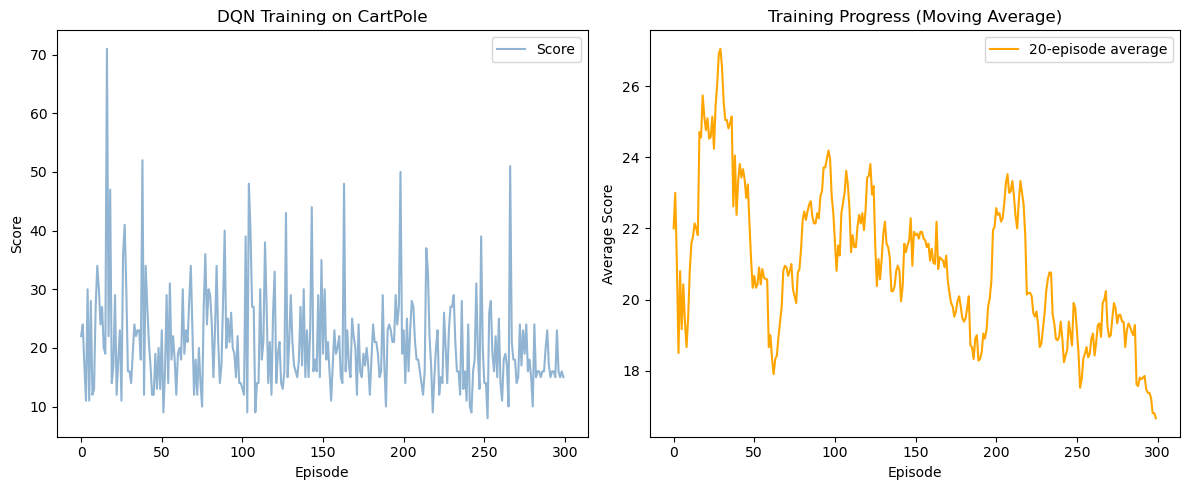

Training curve saved to results/


In [4]:
# Plot the training curve
plt.figure(figsize=(12, 5))

# Raw scores
plt.subplot(1, 2, 1)
plt.plot(scores, alpha=0.6, color='steelblue', label='Score')
plt.xlabel('Episode')
plt.ylabel('Score')
plt.title('DQN Training on CartPole')
plt.legend()

# Moving average
plt.subplot(1, 2, 2)
window = 20
moving_avg = [np.mean(scores[max(0, i-window):i+1]) for i in range(len(scores))]
plt.plot(moving_avg, color='orange', label=f'{window}-episode average')
plt.xlabel('Episode')
plt.ylabel('Average Score')
plt.title('Training Progress (Moving Average)')
plt.legend()

plt.tight_layout()
plt.savefig('../results/dqn_preview_training_curve.png', dpi=150)
plt.show()
print("Training curve saved to results/")